(1000000.0, 1000000000000.0)

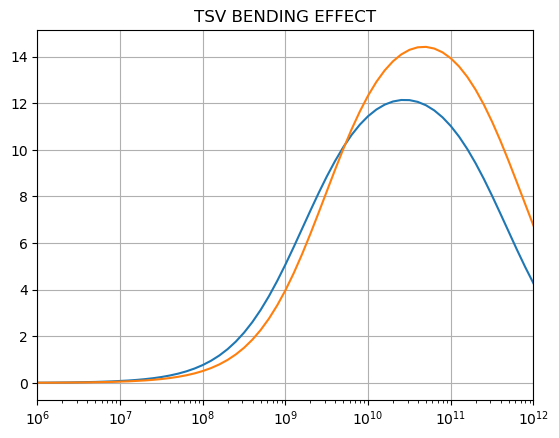

In [25]:
import numpy as np
import matplotlib.pyplot as plt

def compute_composite_bending(E1, H1, E2, H2, sigma):
    """
    E1, H1: 위층 (상부) 탄성계수 및 두께
    E2, H2: 아래층 (하부) 탄성계수 및 두께
    kappa: 곡률
    """
    H_total = H1 + H2

    # 중립면 위치 z_n (아래쪽 기준)
    zn = (E1 * H1 * (H2 + H1 / 2) + E2 * H2 * (H2 / 2)) / (E1 * H1 + E2 * H2)

    # 굽힘 강성 D
    D1 = (E1 / 3) * ((H_total - zn) ** 3 - (H2 - zn) ** 3)
    D2 = (E2 / 3) * ((H2 - zn) ** 3 - (-zn) ** 3)
    D = D1 + D2

    # 회전 모멘트 계산 (상부 응력만 사용)
    z_top = H2 + H1
    M = 0.5 * sigma * ((z_top - zn) ** 2 - (H2 - zn) ** 2)

    return {
        "z_n": zn,
        "D": D,
        "M": M
    }

# 예제 입력
E1 = 130e9  # GPa → Pa
H1 = 30e-6  # µm → m
E2 = 10**(np.arange(1,15,0.1))    # GPa → Pa
H2 = 65e-6  # µm → m
sigma = 100e6  # 상부 응력력

result = compute_composite_bending(E1, H1, E2, H2, sigma)


plt.plot(E2, result["M"] / result["D"])


# 예제 입력
E1 = 130e9  # GPa → Pa
H1 = 30e-6  # µm → m
E2 = 10**(np.arange(1,15,0.1))    # GPa → Pa
H2 = 50e-6  # µm → m
sigma = 100e6  # 상부 응력력

result = compute_composite_bending(E1, H1, E2, H2, sigma)


plt.plot(E2, result["M"] / result["D"])



plt.semilogx()
plt.title('TSV BENDING EFFECT')
plt.grid()
plt.xlim(1e6, 1e12)


(1000000.0, 1000000000000.0)

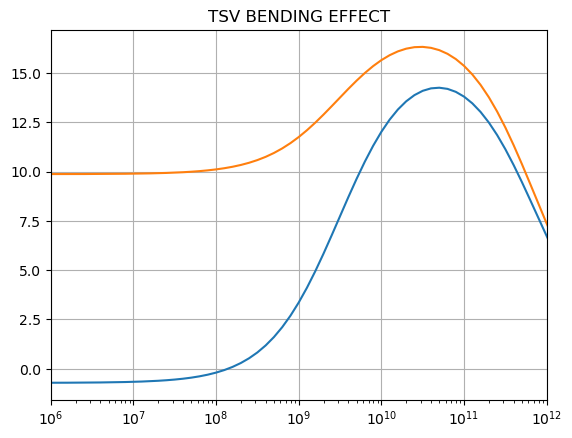

In [29]:
def compute_3layer_moment_and_stiffness(E1, H1, sigma1,
                                        E2, H2, sigma2,
                                        E3, H3):
    # 층 중심 좌표 (기준면: 하단)
    z1 = H3 + H2 + H1 / 2
    z2 = H3 + H2 / 2
    z3 = H3 / 2

    # 중립면 위치 (하단 기준)
    zn = (E1 * H1 * z1 + E2 * H2 * z2 + E3 * H3 * z3) / (E1 * H1 + E2 * H2 + E3 * H3)

    # 각 층 경계 (z 하단, z 상단)
    z1_low, z1_up = H3 + H2, H3 + H2 + H1
    z2_low, z2_up = H3, H3 + H2
    z3_low, z3_up = 0, H3

    # 회전 모멘트 계산 (응력 * 1차 모멘트)
    def moment_from_sigma(sigma, z_low, z_up, zn):
        return sigma * 0.5 * ((z_up - zn)**2 - (z_low - zn)**2)

    M1 = moment_from_sigma(sigma1, z1_low, z1_up, zn)
    M2 = moment_from_sigma(sigma2, z2_low, z2_up, zn)
    M_total = M1 + M2  # 하부는 무응력

    # 굽힘 강성 D = Σ E_i ∫(z - zn)^2 dz
    def bending_stiffness(E, z_low, z_up, zn):
        return E / 3 * ((z_up - zn)**3 - (z_low - zn)**3)

    D1 = bending_stiffness(E1, z1_low, z1_up, zn)
    D2 = bending_stiffness(E2, z2_low, z2_up, zn)
    D3 = bending_stiffness(E3, z3_low, z3_up, zn)
    D_total = D1 + D2 + D3

    # 곡률
    kappa = M_total / D_total

    return {
        "z_n": zn,
        "M_total": M_total,
        "D_total": D_total,
        "kappa": kappa
    }

# 예제 입력
E1 = 10e9      # Pa (중간 층)
H1 = 2e-6     # m
sigma1 = 1e6  # Pa


E2 = 130e9     # Pa (상부 실리콘)
H2 = 30e-6     # m
sigma2 = 100e6 # Pa


E3 = 10**(np.arange(1,15,0.1))      # Pa (하부 글루)
H3 = 50e-6     # m

result = compute_3layer_moment_and_stiffness(E1, H1, sigma1,
                                             E2, H2, sigma2,
                                             E3, H3)

plt.plot(E3, result["M_total"] / result["D_total"])





# 예제 입력
E1 = 10e9      # Pa (중간 층)
H1 = 2e-6     # m
sigma1 = 100e6  # Pa


E2 = 130e9     # Pa (상부 실리콘)
H2 = 30e-6     # m
sigma2 = 100e6 # Pa


E3 = 10**(np.arange(1,15,0.1))      # Pa (하부 글루)
H3 = 50e-6     # m

result = compute_3layer_moment_and_stiffness(E1, H1, sigma1,
                                             E2, H2, sigma2,
                                             E3, H3)

plt.plot(E3, result["M_total"] / result["D_total"])




plt.semilogx()
plt.title('TSV BENDING EFFECT')
plt.grid()
plt.xlim(1e6, 1e12)

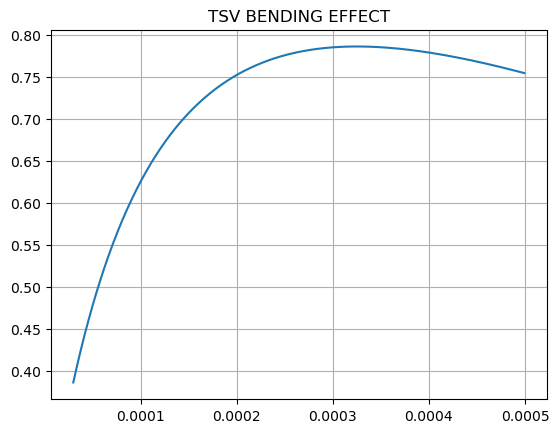

In [74]:
def compute_4layer_moment_and_stiffness(E, H, sigma):
    """
    E: list of modulus [E1, E2, E3, E4] (top to bottom)
    H: list of thickness [H1, H2, H3, H4] (top to bottom)
    sigma: list of stress [σ1, σ2, σ3] (top 3 layers only), σ4 is assumed 0
    """

    # 층 수
    n = 4
    assert len(E) == n and len(H) == n

    # 각 층의 하부 기준 높이 계산
    z_bottom = [0]
    for i in range(1, n):
        z_bottom.append(z_bottom[i-1] + H[n - i])  # 하부부터 누적

    z_bottom = z_bottom[::-1]  # 상부 기준으로 뒤집기

    # 각 층 중심 좌표
    z_center = [z_bottom[i] + H[i]/2 for i in range(n)]

    # 중립면 위치 z_n
    numerator = sum(E[i] * H[i] * z_center[i] for i in range(n))
    denominator = sum(E[i] * H[i] for i in range(n))
    z_n = numerator / denominator

    # 회전 모멘트 (상부 3층만 응력 있음)
    def moment_from_sigma(sigma_i, z_low, z_up, z_n):
        return sigma_i * 0.5 * ((z_up - z_n)**2 - (z_low - z_n)**2)

    M_total = 0.0
    for i in range(3):  # 상부 3층만 응력 부여
        z_low = z_bottom[i]
        z_up = z_bottom[i] + H[i]
        M_total += moment_from_sigma(sigma[i], z_low, z_up, z_n)

    # 굽힘 강성
    def bending_stiffness(Ei, z_low, z_up, zn):
        return Ei / 3 * ((z_up - zn)**3 - (z_low - zn)**3)

    D_total = 0.0
    for i in range(n):
        z_low = z_bottom[i]
        z_up = z_bottom[i] + H[i]
        D_total += bending_stiffness(E[i], z_low, z_up, z_n)

    # 곡률
    kappa = M_total / D_total

    return {
        "z_n": z_n,
        "M_total": M_total,
        "D_total": D_total,
        "kappa": kappa
    }

E3 = np.arange(30e-6, 500e-6, 1e-6)      # Pa (하부 글루)

# 예시 입력
E = [130e9, 130e9, 100e6, 70e9]         # 상부 → 하부 (Pa)
H = [2e-6, E3, 65e-6, 1000e-6]     # 각 층 두께 (m)
sigma = [1000e6, 100e6, 0e6]          # 상부 3개 층에만 응력 (Pa)

result = compute_4layer_moment_and_stiffness(E, H, sigma)

plt.plot(E3, result["M_total"] / result["D_total"])



plt.title('TSV BENDING EFFECT')
plt.grid()


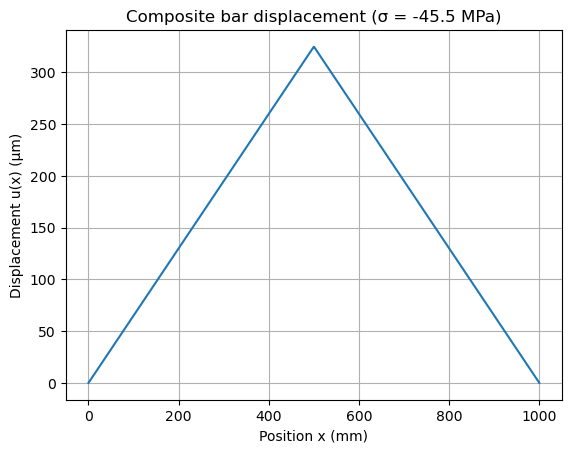

In [76]:
def composite_bar_displacement(E1, E2, a, L, e, N=1000):
    import numpy as np

    x = np.linspace(0, L, N)
    sigma = -e * a / (a / E1 + (L - a) / E2)

    u = np.zeros_like(x)
    for i, xi in enumerate(x):
        if xi <= a:
            u[i] = (sigma / E1 + e) * xi
        else:
            u[i] = (sigma / E2) * xi - (sigma / E2) * L
    return x, u, sigma

# 예시
E1 = 130e9  # Pa
E2 = 70e9
a = 0.5    # m
L = 1.0     # m
e = 1e-3    # 열팽창률

x, u, sigma = composite_bar_displacement(E1, E2, a, L, e)

import matplotlib.pyplot as plt
plt.plot(x * 1e3, u * 1e6)
plt.xlabel("Position x (mm)")
plt.ylabel("Displacement u(x) (μm)")
plt.title(f"Composite bar displacement (σ = {sigma/1e6:.1f} MPa)")
plt.grid(True)
plt.show()
